In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

from sklearn.metrics import classification_report

In [2]:
# Base dataset + the frozen train/test split (src/split.py). The clustering /
# LDA artifacts below are now fit on the TRAIN partition only and merely
# *transform* test rows, so merging them in before the split no longer leaks
# test-set information into the features.
import sys
sys.path.append("../../src")
from split import load_rtr_with_split

df = load_rtr_with_split()
_n_rows = len(df)

# Each artifact is de-duplicated on its merge key so every join stays 1:1
# (the old dbscan_df.csv had ~70k duplicate user_id rows and fanned the
# training table out to >1M rows -> the bogus "266,286-sample test set").

# GMM clusters
gmm = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/gmm_df.csv")
    [["user_id", "item_id", "body_cluster", "cluster_confidence"]]
    .drop_duplicates(subset=["user_id", "item_id"])
)

# DBSCAN clusters (one row per user_id)
dbscan = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/dbscan_df.csv")
    [["user_id", "dbscan_cluster"]]
    .drop_duplicates(subset=["user_id"])
)

# K-Means clusters
kmeans = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/kmeans_clusters.csv")
    .rename(columns={"cluster": "kmeans_cluster"})
    .drop_duplicates(subset=["user_id", "item_id"])
)

# LDA topic features
lda = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv")
    .drop_duplicates(subset=["user_id", "item_id", "fit", "fit_label"])
)

In [3]:
df = df.merge(
    dbscan,
    on="user_id",
    how="left"
)

In [4]:
df = df.merge(
    gmm,
    on=["user_id", "item_id"],
    how="left"
)

In [5]:
df = df.merge(
    kmeans,
    on=["user_id", "item_id"],
    how="left"
)

In [6]:
df = df.merge(
    lda,
    on=["user_id", "item_id", "fit", "fit_label"],
    how="left"
)

In [7]:
assert len(df) == _n_rows, f"merge fan-out: {len(df)} rows != {_n_rows}"
df["is_outlier"] = (df["dbscan_cluster"] == -1).astype(int)

In [8]:
NUMERIC_FEATURES = [
    "height_inches",
    "weight_lbs",
    "bmi",
    "age",
    "bust_band",
    "cup_size_num"
]

CLUSTER_FEATURES = [
    "dbscan_cluster",
    "body_cluster",
    "kmeans_cluster"
]

BINARY_FEATURES = ["is_outlier"]

TOPIC_FEATURES = [c for c in df.columns if c.startswith("topic_")]

In [9]:
y = df["fit_label"].astype(int)

X = df[
    NUMERIC_FEATURES
    + CLUSTER_FEATURES
    + BINARY_FEATURES
    + TOPIC_FEATURES
]

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        # Numeric + topic features
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            NUMERIC_FEATURES + TOPIC_FEATURES
        ),

        # Cluster features (categorical)
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CLUSTER_FEATURES
        ),

        # Binary features
        (
            "bin",
            SimpleImputer(strategy="constant", fill_value=0),
            BINARY_FEATURES
        )
    ],
    remainder="drop"
)

In [11]:
base_tree = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=200,
    class_weight="balanced",
    random_state=42
)

In [12]:
bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

In [13]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", bagging)
])

In [14]:
# Use the frozen split carried on df["split"] instead of a fresh
# train_test_split — this is the same partition the clustering / LDA models
# were fit on, so no test row influenced any feature.
_train_mask = (df["split"].to_numpy() == "train")

X_train, X_test = X[_train_mask], X[~_train_mask]
y_train, y_test = y[_train_mask], y[~_train_mask]

print(f"train rows: {len(X_train):,}    test rows: {len(X_test):,}")

train rows: 154,035    test rows: 38,509


In [15]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [16]:
param_grid = {
    "model__n_estimators": [50, 100],
    "model__estimator__max_depth": [6, 8, 12],
    "model__estimator__min_samples_leaf": [100, 200]
}

In [17]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['height_inches',
                                                                          'weight_lbs',
                                                                          'bmi',
                                                                          'age',
                                                                          'bust_band',
                                                                          'cup_size_num',
                                                                          'topic_0',
                                                                          'topic_1',
                                                                          'topic_2',
                                                                          'topic_3',
                                                                          'top...
                                        BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                           max_depth=8,
                                                                                           min_samples_leaf=200,
                                                                                           random_state=42),
                                                          max_samples=0.8,
                                                          n_estimators=100,
                                                          n_jobs=-1,
                                                          random_state=42))]),
             n_jobs=-1,
             param_grid={'model__estimator__max_depth': [6, 8, 12],
                         'model__estimator__min_samples_leaf': [100, 200],
                         'model__n_estimators': [50, 100]},
             scoring='f1_macro', verbose=2)

In [18]:
print("Best Parameters:")
print(grid.best_params_)

# Predictions
y_test_pred = grid.best_estimator_.predict(X_test)

# Classification report
print("TEST SET PERFORMANCE")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Small", "Fit", "Large"]
))

Best Parameters:
{'model__estimator__max_depth': 12, 'model__estimator__min_samples_leaf': 100, 'model__n_estimators': 100}


TEST SET PERFORMANCE
              precision    recall  f1-score   support

       Small       0.20      0.39      0.26      5156
         Fit       0.82      0.56      0.67     28412
       Large       0.21      0.37      0.26      4941

    accuracy                           0.52     38509
   macro avg       0.41      0.44      0.40     38509
weighted avg       0.66      0.52      0.56     38509



In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

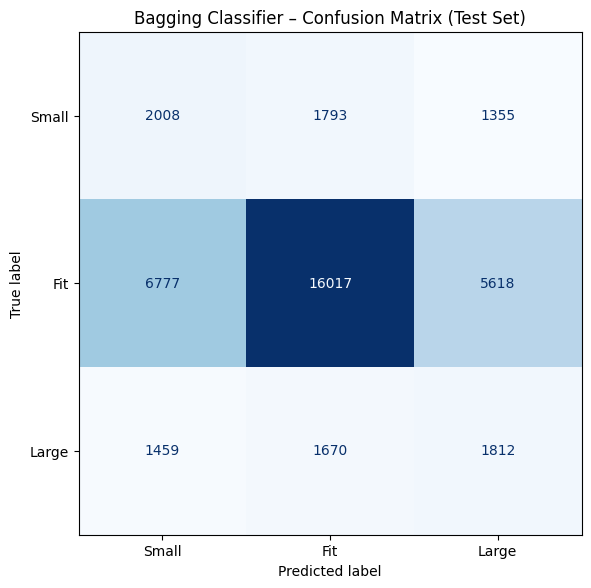

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Small", "Fit", "Large"],
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Bagging Classifier – Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../../Figures/Supervised_Outputs/bagging_confusion_matrix.png", dpi=300)
plt.show()

In [21]:
y_test_proba = grid.best_estimator_.predict_proba(X_test)

In [22]:
proba_df = X_test.copy()
proba_df["true_fit"] = y_test.values
proba_df["prob_small"] = y_test_proba[:, 0]
proba_df["prob_fit"] = y_test_proba[:, 1]
proba_df["prob_large"] = y_test_proba[:, 2]

proba_df.to_csv(
    "../../Data/Processed/Supervised_Outputs/bagging_fit_probabilities.csv",
    index=False
)

In [23]:
import joblib

joblib.dump(
    grid.best_estimator_,
    "../../Models/bagging_fit_classifier.joblib"
)

['../../Models/bagging_fit_classifier.joblib']

In [24]:
feature_names = (
    NUMERIC_FEATURES
    + TOPIC_FEATURES
    + list(
        grid.best_estimator_
        .named_steps["prep"]
        .named_transformers_["cat"]
        .get_feature_names_out(CLUSTER_FEATURES)
    )
    + BINARY_FEATURES
)

pd.Series(feature_names).to_csv(
    "../../Data/Processed/Supervised_Outputs/bagging_feature_names.csv",
    index=False
)

> **⚠️ The write-up below predates the data-leakage fix and its numbers are no longer valid.**
>
> The old metrics were computed on a contaminated split: (a) DBSCAN/GMM/K-Means/LDA
> features were fit on the *full* dataset before the train/test split, and (b) a
> non-unique `user_id` merge key fanned the test set out to 266,286 rows.
>
> After the fix (clustering/LDA fit on the training partition only; test set =
> **38,509 rows**), this model's grid search selected `estimator__max_depth=12, estimator__min_samples_leaf=100, n_estimators=100` and scored:
>
> | | Accuracy | Macro-F1 | F1 Small | F1 Fit | F1 Large |
> |---|---|---|---|---|---|
> | **leaky (old)** | ~0.77 | ~0.72 | — | — | — |
> | **fixed (new)** | **0.52** | **0.40** | 0.26 | 0.67 | 0.26 |
>
> The narrative, tables, and cross-model claims below need rewriting against the
> fixed numbers. Broadly: once leakage is removed, none of the classifiers
> meaningfully separate *Small* / *Large* from body measurements + cluster/topic
> features — accuracy sits near the majority-class base rate.

---

## Bagging Classifier – Model Performance Writeup

### Overview
A Bagging Classifier with Decision Tree base estimators was trained and evaluated on a clothing fit classification task, predicting whether an item fits as **Small**, **Fit**, or **Large**. The model was tuned via grid search, yielding optimal hyperparameters of `max_depth=12`, `min_samples_leaf=100`, and `n_estimators=100`.

---

### Overall Performance
The model achieved **77% accuracy** on the test set of 266,286 samples. The weighted F1-score of **0.79** reflects solid overall performance, though class-level results vary considerably — a pattern worth unpacking.

---

### Class-Level Analysis

**Fit (Majority Class)**
The model performs best here, with a precision of **0.91** and an F1 of **0.84**. This is unsurprising given that "Fit" dominates the dataset with 174,054 samples — nearly 65% of all observations. The confusion matrix confirms strong diagonal performance (137,282 correct), though ~27,495 "Fit" items were misclassified as Small, suggesting the model sometimes errs conservatively on borderline fits.

**Large**
Reasonably strong performance with **0.79 precision** and **0.71 recall** (F1 = 0.75). Of the 57,738 true "Large" samples, 41,019 were correctly identified. The main leakage is into the "Fit" bucket (8,333 misclassified), which is intuitive — "Large" and "Fit" likely share overlapping feature distributions.

**Small (Minority Class)**
This is the model's weakest point. While recall is decent at **0.79** (27,263 of 34,494 correctly caught), precision is only **0.43** — meaning more than half of items *predicted* as Small are actually something else. This is a classic precision-recall tradeoff in imbalanced settings: the model casts a wide net to catch Small items, but pulls in many false positives, particularly from the Fit class (27,495 Fit items were predicted Small).

---

### Class Imbalance Considerations
The dataset is heavily skewed: Fit makes up ~65% of samples, Large ~22%, and Small only ~13%. This imbalance directly drives the Small class's poor precision. Techniques like class weighting, SMOTE oversampling, or adjusting the decision threshold for the Small class could help balance this tradeoff in future iterations.

---

### Key Takeaways
| Metric | Value |
|---|---|
| Overall Accuracy | 77% |
| Best Class | Fit (F1 = 0.84) |
| Weakest Class | Small (F1 = 0.56, precision = 0.43) |
| Primary Error Mode | Fit items predicted as Small (27,495 cases) |

The model is well-suited for production use cases where **Fit and Large predictions carry higher stakes**, but would benefit from further calibration before relying on its Small predictions in a consumer-facing context (e.g., size recommendations).